In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, precision_score, recall_score, accuracy_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import joblib
import os

In [2]:
def load_data():
    """Load California housing dataset"""
    housing = fetch_california_housing()
    df = pd.DataFrame(housing.data, columns=housing.feature_names)
    df['MedHouseVal'] = housing.target
    return df

In [3]:
def preprocess_data(df):
    """Handle missing values and scale features"""
    # Check for missing values
    if df.isnull().sum().max() > 0:
        print("Handling missing values...")
        imputer = SimpleImputer(strategy='median')
        df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
    
    # Split features and target
    X = df.drop('MedHouseVal', axis=1)
    y = df['MedHouseVal']
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test

In [4]:
def analyze_data(df):
    """Perform exploratory data analysis"""
    print("\n=== DATA OVERVIEW ===")
    print(df.info())
    print("\n=== FIRST 5 ROWS ===")
    print(df.head())
    
    print("\n=== STATISTICAL SUMMARY ===")
    print(df.describe())
    
    # Correlation matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Feature Correlation Matrix")
    plt.show()
    
    # Distribution of target variable
    plt.figure(figsize=(8, 6))
    sns.histplot(df['MedHouseVal'], kde=True, bins=30)
    plt.title("Distribution of House Prices")
    plt.xlabel("Median House Value (100,000s)")
    plt.show()
    
    # Feature distributions
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    for i, col in enumerate(df.columns):
        sns.histplot(df[col], ax=axes[i//3, i%3], kde=True)
        axes[i//3, i%3].set_title(f'{col} Distribution')
    plt.tight_layout()
    plt.show()

In [5]:
def train_models(X_train, X_test, y_train, y_test):
    """Train and evaluate multiple regression models"""
    models = {
        'Linear Regression': LinearRegression(),
        'Lasso Regression': Lasso(alpha=0.1),
        'Ridge Regression': Ridge(alpha=1.0),
        'Random Forest': RandomForestRegressor(random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42)
    }
    
    results = {}
    
    for name, model in models.items():
        print(f"\nTraining {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Calculate metrics
        metrics = {
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred),
            'R2': r2_score(y_test, y_pred)
        }
        
        results[name] = {
            'model': model,
            'metrics': metrics,
            'predictions': y_pred
        }
        
        print(f"{name} Results:")
        for metric, value in metrics.items():
            print(f"{metric}: {value:.4f}")
    
    return results

In [6]:
def hyperparameter_tuning(X_train, y_train):
    """Perform hyperparameter tuning using GridSearchCV"""
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }
    
    rf = RandomForestRegressor(random_state=42)
    grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print("\nBest Parameters:", grid_search.best_params_)
    best_rf = grid_search.best_estimator_
    
    return best_rf

In [7]:
def feature_importance(model, feature_names):
    """Plot feature importance for tree-based models"""
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x=feat_imp, y=feat_imp.index)
        plt.title("Feature Importance")
        plt.xlabel("Importance Score")
        plt.ylabel("Features")
        plt.show()
        
        return feat_imp
    return None


=== DATA OVERVIEW ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

=== FIRST 5 ROWS ===
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.07

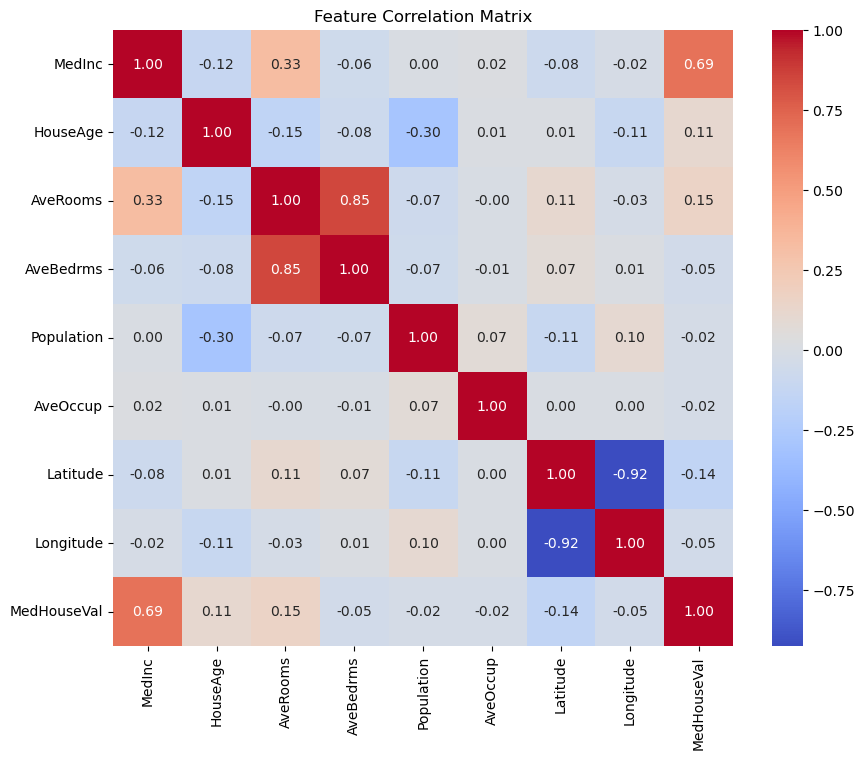

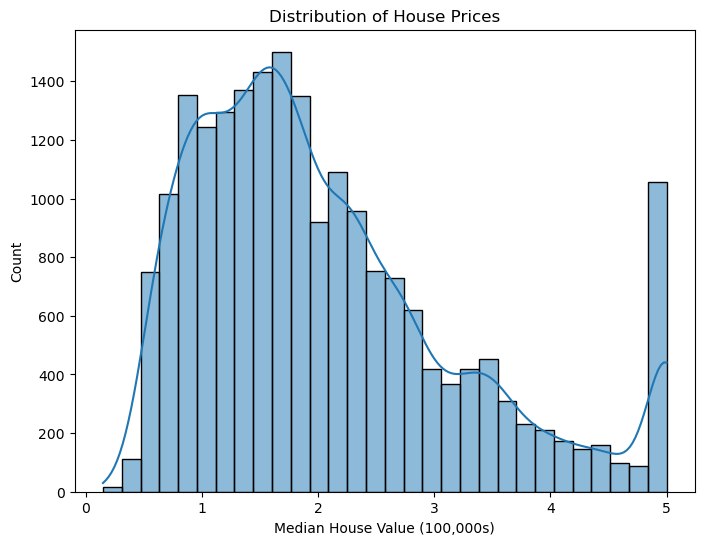

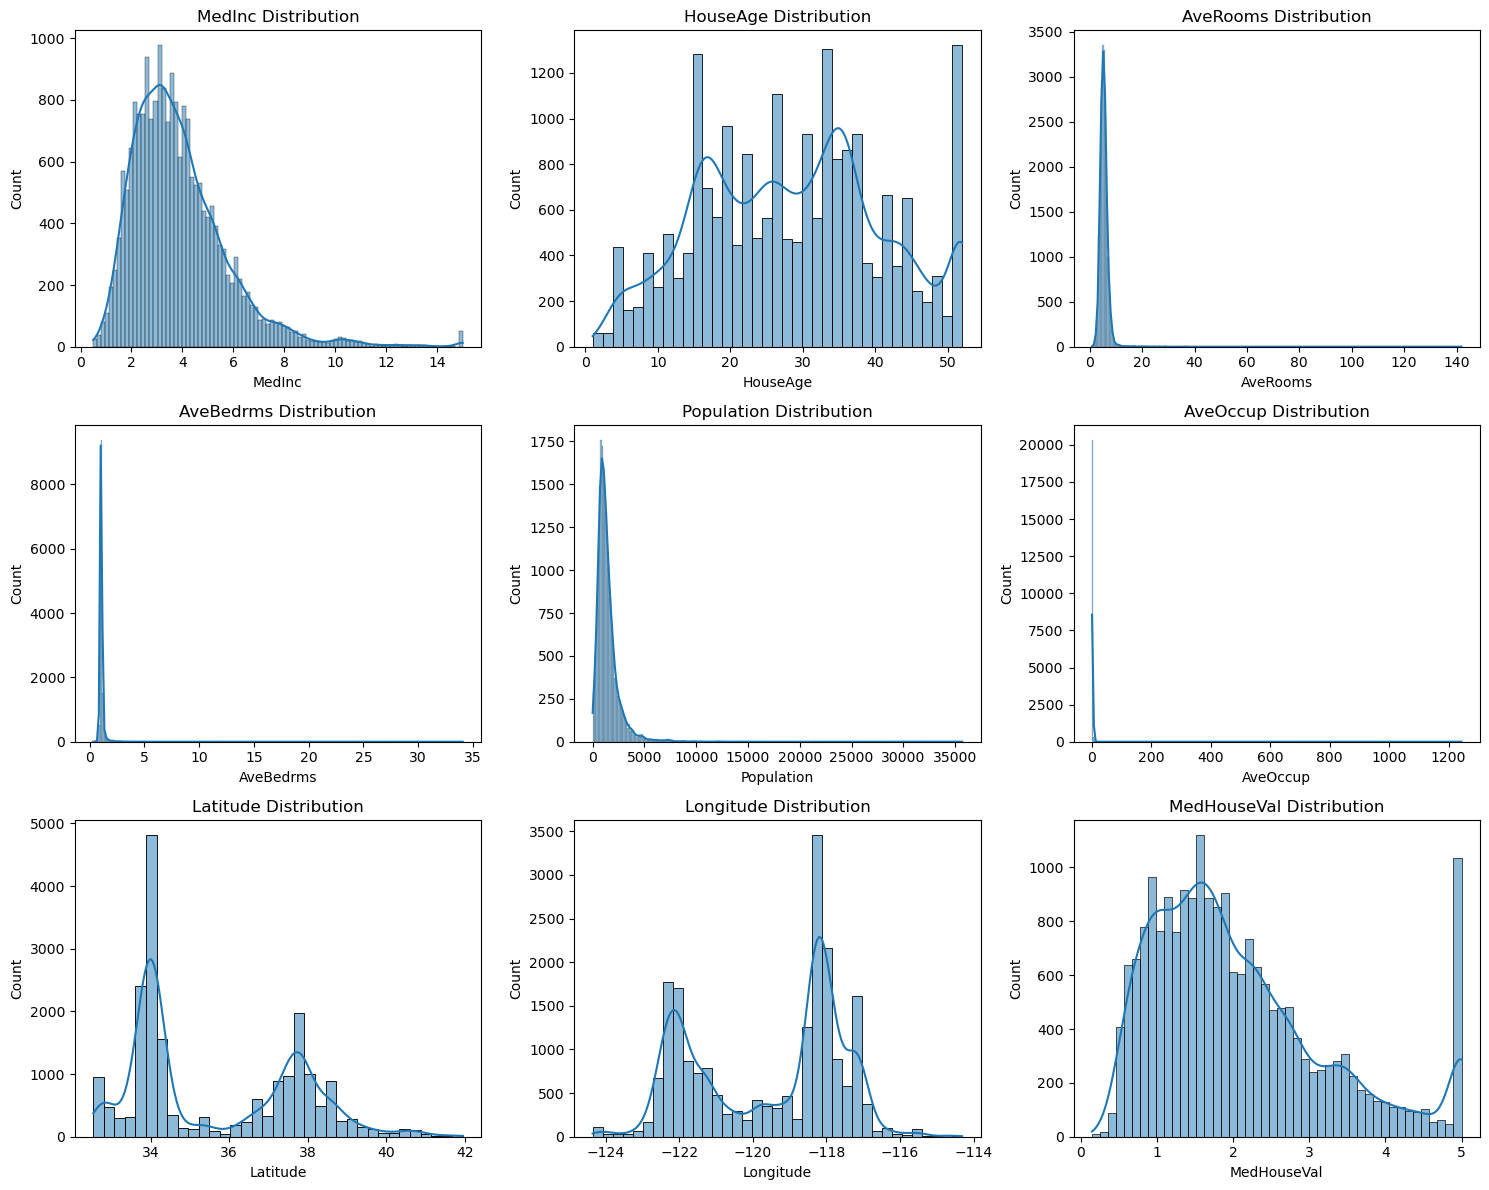

In [8]:
# Load data
df = load_data()
analyze_data(df)

In [9]:
# Preprocess data
X_train, X_test, y_train, y_test = preprocess_data(df)

In [10]:
# Train models
results = train_models(X_train, X_test, y_train, y_test)


Training Linear Regression...
Linear Regression Results:
RMSE: 0.7284
MAE: 0.5272
R2: 0.5958

Training Lasso Regression...
Lasso Regression Results:
RMSE: 0.8154
MAE: 0.6165
R2: 0.4935

Training Ridge Regression...
Ridge Regression Results:
RMSE: 0.7284
MAE: 0.5272
R2: 0.5958

Training Random Forest...
Random Forest Results:
RMSE: 0.5066
MAE: 0.3323
R2: 0.8044

Training Gradient Boosting...
Gradient Boosting Results:
RMSE: 0.5369
MAE: 0.3714
R2: 0.7803


In [ ]:
# Hyperparameter tuning
best_rf = hyperparameter_tuning(X_train, y_train)

In [ ]:
# Feature importance analysis
feature_names = df.columns[:-1]
feat_imp = feature_importance(best_rf, feature_names)

In [ ]:
# Save best model
if not os.path.exists('models'):
    os.makedirs('models')
joblib.dump(best_rf, 'models/best_rf_model.pkl')
print("\nBest model saved to models/best_rf_model.pkl")



In [ ]:
# Cross-validation
    cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='r2')
    print(f"\nCross-Validation R2 Scores: {cv_scores}")
    print(f"Mean CV R2: {np.mean(cv_scores):.4f}")

if __name__ == "__main__":
    main()